# Modelo de Resultados Potenciais

Prof. Daniel de Abreu Pereira Uhr


### Conteúdo

* Resultados Potencias
  * Notações e Conceitos Iniciais
  * Efeito Médio do Tratamento
  * Efeito Médio do Tratamento sobre os Tratados
  * Efeito Médio do Tratamento sobre os Não Tratados
  * Decomposição de Médias
  * Estimador para o ATE
  * Diferenças do uso da SDO entre o ATE e o ATT

* Método Experimental
  * Suposição de Independência e Randomized Controlled Trials (RCTs - A/B-tests)
  * SUTVA
  * Randomized Controlled Trials (RCT) e Regressão Linear
  * RCT em termos de regressão linear

* Considerações Finais


### Referências


* Cunningham, S. W. (2013). Causal inference: The mixtape. https://mixtape.scunning.com/ 
* Facure, Matheus. Causal Inference for Brave and True. https://matheusfacure.github.io/python-causality-handbook/landing-page.html ​​
* Joshua D. Angrist and Jörn-Steffen Pischke (2009). Mostly Harmless Econometrics: An Empiricist's Companion. Princeton University Press.
* Hernan, M. Causal Inference: What If (the book). https://www.hsph.harvard.edu/miguel-hernan/causal-inference-book/ 
* [Avaliação Econômica de Projetos Sociais. Itaú Social, 2017](https://www.itausocial.org.br/wp-content/uploads/2018/05/avaliacao-economica-3a-ed_1513188151.pdf). Capítulos 1, 2 e 3. 
* Splawa-Neyman, J. (1923). On the Application of Probability Theory to Agricultural Experiments. Essay on Principles. Section 9. Statistical Science, 5(4), 465–472. https://www.jstor.org/stable/2245382
* Rubin D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. Journal of Educational Psychology, 66(5), 688–701. https://doi.org/10.1037/h0037350
* Notas próprias.​

## Resultados Potenciais

Embora a **notação de resultados potenciais** remonte a Splawa-Neyman ( 1923 ), obteve um grande impulso nas ciências sociais aplicadas com D. Rubin ( 1974 ). Atualmente, esse tipo de abordagem tomou o protagonismo nas principais revistas científicas. **Na tradição de resultados potenciais** (Splawa-Neyman 1923; D. Rubin 1974 ), **um efeito causal é definido como uma comparação entre dois estados do mundo**. 

Por exemplo, no primeiro estado do mundo (**estado "factual"** ou “real” do mundo), uma empresa adota uma nova tecnologia para automação do processo produtivo e um ano depois relata seu nível de produtividade. No segundo estado do mundo (**estado “contrafactual”** do mundo), essa mesma empresa não adota uma nova tecnologia para automação do processo produtivo e um ano depois relata seu nível de produtividade. 

Qual foi o efeito causal da adocação da tecnologia de automação industrial? 

De acordo com a tradição dos resultados potenciais, **o efeito causal da tecnologia sobre o processo de produção** é a **diferença na produtividade entre dois estados do mundo**: um onde foi adotada a tecnologia (o estado **factual**/real do mundo) e outro onde ele nunca adotou a tecnologia (o estado **contrafactual** do mundo). A diferença na produtividade entre esses dois estados do mundo é o efeito causal da adoção da tecnologia. A ideia central é essa! 

Repare que estamos construindo um raciocínio comparativo entre a empresa que sofreu a intervenção, e a mesma empresa caso não tivesse sofrido a intervenção. (Por que?)

### Notações e Conceitos Iniciais

Vamos introduzir algumas notações e conceitos mais específicos. Cada empresa $i$ apresenta uma medida de produtividade (resultado/outcome) $Y_{i}$, que pode ser observada em dois estados do mundo, $Y_{i}^{1}$ caso a empresa tenha sofrido a intervenção ($D=1$) e $Y_{i}^{0}$ caso contrário ($D=0$). Essas variáveis são factuais (reais e/ou observáveis).

**A ideia de resultados potenciais é um arcabouço hipotético**. E a forma de como passamos dos resultados potenciais para os resultados reais é um grande passo filosófico.

Então, o ***problema fundamental da inferência causal*** é que nunca podemos observar o mesmo indivíduo sob diferentes condições de tratamento:

$$
Y^{obs}_i(D)= 
\begin{cases}
Y_i(1), & \text{se } D=1 \\
Y_i(0), & \text{se } D=0
\end{cases}
$$

Ou seja, o resultado observável de uma unidade é uma função dos seus resultados potenciais determinados de acordo com a **equação de comutação** (switching equation):

>
> $$ Y_{i} = D_{i}Y_{i}(1) + (1-D_{i})Y_{i}(0) $$
>

Onde $D_{i}$ é uma variável binária que indica se a unidade $i$ sofreu a intervenção ($D_{i}=1$) ou não ($D_{i}=0$). Observe a lógica da equação, quando $D_{i}=1$, o resultado observável é igual ao resultado potencial $Y_{i}^{1}$, e quando $D_{i}=0$, o resultado observável é igual ao resultado potencial $Y_{i}^{0}$.


***Individual Treatment Effect - ITE - $\beta_{i}$***

Usando essa notação, podemos definir **o efeito causal individual** (ITE - *Individual Treatment Effect*) da intervenção como a diferença entre os resultados potenciais do estado factual e contrafactual da unidade $i$:

$$ 
\beta_{i}^{ITE} = Y_{i}(1) - Y_{i}(0) 
$$

Reparem que temos um problema, se o efeito causal exige o conhecimento dos dois estados da natureza, mas pela equação de comutação observamos apenas um estado para cada indivíduo, então **não podemos calcular diretamente o efeito causal**. É aqui que reside o **problema fundamental da inferência causal**: a certeza em torno dos efeitos causais requer acesso a dados que estão além do alcance do pesquisador.

***E a Média dos Efeitos para os Diferentes Indivíduos?***

Devido ao **problema fundamental da inferência causal**, podemos entender a questão como um caso de **dados faltantes**: não podemos observar o resultado de um indivíduo sob tratamento e controle simultaneamente. Portanto, **não podemos observar o efeito causal de um tratamento em um indivíduo**. O que podemos observar são os resultados de um indivíduo tratado ou não-tratado, mas não em ambos.

$$ Y_{i} = D Y^{1}_{i} + (1-D)Y^{0}_{i} $$

rearrajando a equação, temos:

$$ Y_{i} = Y^{0}_{i} + (Y^{1}_{i} - Y^{0}_{i})D $$

Vamos chamar o ***efeito causal individual*** (ITE) é a diferença nos dois estados da natureza, que vamos denotar aqui como $\beta_{ITE}$, então:

$$ Y_{i} = Y^{0}_{i} + \beta_{ITE} D $$


Quando possuímos uma amostra, podemos avaliar o efeito médio (Efeito Médio do Tratamento - Average Treatment Effect - ATE). Aplicando a esperança de $Y_{i}$, temos:

$$ E[Y_{i}] = E[Y^{0}_{i}] + E[\beta_{ITE}]E[D] $$

E as médias condicionais:

$$ E[Y_{i}|D=1] = E[Y^{1}_{i}] = E[Y^{0}_{i}] + E[\beta_{ITE}] $$

$$ E[Y_{i}|D=0] = E[Y^{0}_{i}] $$


repare que a diferença entre as médias condicionais (média dos tratados e a média dos não tratados) é o efeito médio do tratamento (ATE):

$$ ATE = E[Y_{i}|D=1] - E[Y_{i}|D=0] = E[Y^{1}_{i}] - E[Y^{0}_{i}] = E[\beta_{ITE}] $$

Você está me dizendo que o efeito médio do tratamento é uma diferença entre duas médias? ***Sim!***

Você está me dizendo que regressões lineares podem ser vistas como diferença entre médias? ***Sim!***

***Não acredito nisso!***

Então veja você mesmo numa aplicação em Python:


In [1]:
import pandas as pd
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
import seaborn as sns

In [2]:
# DataFrame do peso dos bebês ao nascer
df = pd.read_stata("https://github.com/Daniel-Uhr/data/raw/main/cattaneo2.dta")

In [3]:
# Ajustando as variáveis
# Criar a variável de resultado (Y)
df['Y'] = df['bweight']
# Crie a variável 'Treated' com valor inicial de 0
df['Treated'] = 0
# Recodifique 'Treated' para 1 se 'mbsmoke' for igual a 'smoker'
df.loc[df['mbsmoke'] == 'smoker', 'Treated'] = 1

<Axes: xlabel='Y', ylabel='Density'>

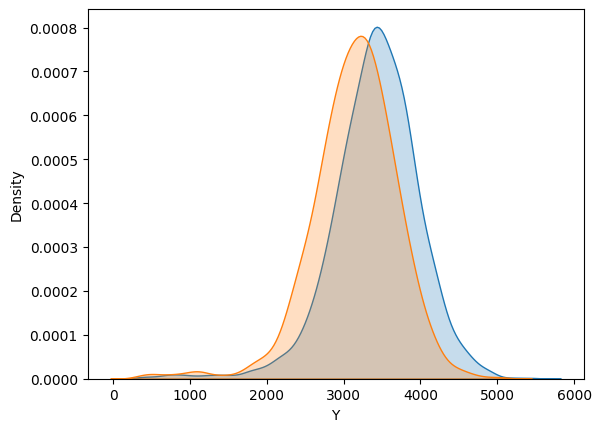

In [4]:
# Plotando a distribuição do peso dos bebês ao nascer
sns.kdeplot(df[df['Treated'] == 0]['Y'], fill=True, label='Não fumantes')
sns.kdeplot(df[df['Treated'] == 1]['Y'], fill=True, label='Fumantes')

Vamos verificar a média do peso dos bebês para as mães não fumantes.

In [5]:
df[df['Treated'] == 0]['Y'].mean()

np.float64(3412.91159343568)

Vamos verificar a média do peso dos bebês para as mães fumantes.

In [6]:
df[df['Treated'] == 1]['Y'].mean()

np.float64(3137.659722222222)

diferença entre as médias dos bebês para as mães fumantes e não fumantes.

In [7]:
df[df['Treated'] == 1]['Y'].mean() - df[df['Treated'] == 0]['Y'].mean()

np.float64(-275.2518712134579)

In [8]:
# Gerar um teste-t para comparar a média do peso do bebê entre fumantes e não fumantes
grupo_fumantes = df[df['Treated'] == 1]['Y']
grupo_nao_fumantes = df[df['Treated'] == 0]['Y']

# Realizar o teste-t - se e estatisticamente signficativo
teste_t = ttest_ind(grupo_fumantes, grupo_nao_fumantes)
print(teste_t)

TtestResult(statistic=np.float64(-12.830577987447224), pvalue=np.float64(4.683726413107466e-37), df=np.float64(4640.0))


E se fizermos uma regressão linear com a variável fumante como variável explicativa?


In [10]:
import statsmodels.formula.api as smf
reg = smf.ols('Y ~ Treated', data=df).fit()
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     164.6
Date:                Tue, 22 Apr 2025   Prob (F-statistic):           4.68e-37
Time:                        15:02:49   Log-Likelihood:                -36033.
No. Observations:                4642   AIC:                         7.207e+04
Df Residuals:                    4640   BIC:                         7.208e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3412.9116      9.255    368.754      0.0

Repare que os resultados são idênticos à diferença entre médias. Como o efeito de fumar é negativo


Voltando aos conceitos

### Efeito Médio do Tratamento

O **Efeito Médio do Tratamento** (Average Treatment Effect - ATE) é a média do efeito causal individual **da população** (da amostra inteira). (O melhor efeito, o que nos interessa, em termos de politica publica etc.)

>
> $$ ATE = E[\beta_{i}] = E[Y_{i}^{1} - Y_{i}^{0}] = E[Y_{i}^{1}] - E[Y_{i}^{0}] $$
>

O ATE, assim como o efeito causal individual do tratamento, não é uma quantidade que possa ser calculada. Mas poderá ser estimado!


### Efeito Médio do Tratamento Sobre os Tratados

Repare que existem dois grupos de pessoas na discussão: um **grupo de tratamento** e um **grupo de controle**. O efeito médio do tratamento para o grupo de tratamento  (Average Treatment Effect on the Treated - ATT), é simplesmente o efeito médio do tratamento da população para o grupo de unidades ao qual foi atribuído o tratamento em primeiro lugar, de acordo com a equação de comutação. 

Tal como o ATE, o ATT é incognoscível porque, tal como o ATE, também requer duas observações por unidade $i$ de tratamento. Formalmente, escrevemos o ATT como:

>
> $$ ATT = E[\beta_{i}|D_{i}=1] = E[Y_{i}^{1} - Y_{i}^{0}|D_{i}=1] = E[Y_{i}^{1}|D_{i}=1] - E[Y_{i}^{0}|D_{i}=1] $$
>


### Efeito Médio do Tratamento Sobre os Não-Tratados

O último parâmetro de interesse é denominado *efeito médio do tratamento para o grupo controle* (ou grupo não tratado), Average Treatment Effect on the Untreated (ATU). Dados os efeitos heterogênios do tratamento, é provável que $ATT \neq ATU$. A fórmula para o ATU é:

>
> $$ ATU = E[\beta_{i}|D_{i}=0] = E[Y_{i}^{1} - Y_{i}^{0}|D_{i}=0] = E[Y_{i}^{1}|D_{i}=0] - E[Y_{i}^{0}|D_{i}=0] $$
>

o ATU (ou ATNT - Average Treatment Effect on the Non-Treated) mede o impacto que o tratamento teria tido sobre as unidades que não receberam o tratamento. O ATNT nos diz o quanto os indivíduos que não foram tratados teriam se beneficiado (ou prejudicado) se tivessem sido tratados.

Quando eu poderia utilizar o ATU?
* ajuda a estimar os benefícios potenciais para aqueles que ainda não foram expostos à política. Por exemplo, se um programa de transferência de renda for testado em uma região, o ATNT pode medir o impacto que esse programa teria sobre as regiões que ainda não o receberam.
* pode ser usado para tomar decisões sobre expandir ou modificar o tratamento para outros grupos. Se o efeito médio sobre os não-tratados for alto, isso pode indicar que há benefícios significativos em estender o tratamento para outras pessoas ou áreas.

Ou seja, o ATU responde à pergunta: o que teria acontecido com os não tratados, se eles tivessem recebido o tratamento?

Dependendo da questão de investigação, um ou todos estes parâmetros são interessantes. Mas os dois de interesse mais comuns na literatura de avaliação de intervenção econômica são o ATE e o ATT. O ATE é utilizado quando estamos interessados ​​no **tratamento médio de toda a população**, enquanto o ATT é utilizado quando estamos interessados ​​apenas no **efeito médio do tratamento daqueles tratados**.

### Decomposição de Médias

Vamos criar um exemplo fictício para fixar os conceitos (lembre que não existe a possibilidade de um indivíduo apresentar os dois estados da natureza). Considere os dados da tabela para nosso exemplo de adoção de tecnologia nas firmas. A tabela apresenta os Resultados Potencias para 10 empresas que adotariam a tecnologia (reforçando, tenha em mente que esses dados são "ideais" - mundo de Platon, mundo platonico, das ideias).

| Firm | $Y^{1}$ | $Y^{0}$ | $\delta$ |
|------|---------|---------|----------|
| 1    | 7       | 1       | 6        |
| 2    | 5       | 6       | -1       |
| 3    | 5       | 1       | 4        |
| 4    | 7       | 8       | -1       |
| 5    | 4       | 2       | 2        |
| 6    | 10      | 1       | 9        |
| 7    | 1       | 10      | -9       |
| 8    | 5       | 6       | -1       |
| 9    | 3       | 7       | -4       |
| 10   | 9       | 8       | 1        |
|------|---------|---------|----------|
|$\sum$| 56      | 50      | 6        |


Com essa matriz de dados, seria possível calcular o efeito médio do tratamento (ATE), porque o efeito médio seria simplesmente a diferença entre as médias de $Y^{1}$ e $Y^{0}$.

* $E[Y^{1}]$ = 5.6
* $E[Y^{0}]$ = 5

Isso significa que o **ATE é 0.6**. Ou seja, a adoção da tecnologia aumentaria a produtividade em 0,6. Um ponto importante a ser destacado é que a empresa 7 produz apenas mais uma unidade após a adoção da tecnologia. Isso é uma evidência de que nem todos se beneficiaram da adoção da tecnologia.

Vamos aumentar nossa ficção aqui, e supor que além de saber os resultados potenciais de cada empresa, podemos escolher as empresas que maximizam a produtividade para receber o tratamento. Logo, após a atribuição do tratamento, observamos o resultado real pós-tratamento de acordo com a equação de comutação comentada anteriormente:

| Firm | $Y$ | $D$ |
|------|-----|-----|
| 1    | 7   | 1   |
| 2    | 6   | 0   |
| 3    | 5   | 1   |
| 4    | 8   | 0   |
| 5    | 4   | 1   |
| 6    | 10  | 1   |
| 7    | 10  | 0   |
| 8    | 6   | 0   |
| 9    | 7   | 0   |
| 10   | 9   | 1   |

Podemos calcular o **efeito médio do tratamento para o grupo de tratamento** (ATT) e para o grupo de controle (ATU).

* ATT = (6+4+2+9+1)/5 = 22/5 = 4,4
* ATU = [(-1)+(-1)+(-9)+(-1)+(-4)]/5 = -16/5 = -3,2

**Assim, o ATE (resultado de 0,6) é uma média ponderada entre o ATT e o ATU.**

$$ ATE = \phi ATT + (1-\phi)ATU $$

Em termos gerais, $\phi$ é a proporção de tratados. E $(1 - \phi)$ é proporção de não tratados. Para o nosso estudo específico,  $\phi$ de 0.5 .

$$ ATE = (0.5)4.4 + (1-0.5)(-3.2) = 0.6 $$


O efeito global é positivo, embora para alguns seja negativo. Os resultados individuais mostram que existem efeitos heterogêneos (diferenciados entre os indivíduos). Alguns indivíduos apresentam um padrão de resultados positivos, enquanto outros apresentam um padrão de resultados negativos.


### Estimador para o ATE

**E se comparássemos simplesmente a expectativa de produtividade entre os tratados e não tratados** nos nossos dados? Esse estimador simples é uma estimativa para o ATE.

>
> $$ E[Y^{1}|D=1] - E[Y^{0}|D=0] $$
>

Podemos estimá-lo com a amostra de dados que temos (*Simple Difference in Outcomes* - SDO)

$$ SDO = E[Y^{1}|D=1] - E[Y^{0}|D=0] = \frac{1}{N_{T}}\sum_{i=1}^{n}(y_{i}|d_{i}=1) - \frac{1}{N_{C}}\sum_{i=1}^{n}(y_{i}|d_{i}=0)$$

* $E[Y^{1}|D=1]$ = (7+5+4+10+9)/5 = 35/5 = 7
* $E[Y^{0}|D=0]$ = (6+8+10+6+7)/5 = 37/5 = 7,4
* SDO = 7 - 7,4 = -0,4

Ou seja, a adoção da tecnologia diminuiria a produtividade em 0.4 unidades. **Embora a estatística seja verdadeira, observe como ela é enganosa**. Esta estatística sem a devida qualificação poderia facilmente ser usada para afirmar que, em média, a tecnologia é prejudicial, quando sabemos que isso não é verdade. É tendencioso porque as firmas estavam sendo classificadas de maneira ideal sua melhor opção de tratamento, criando diferenças sistemáticas entre o grupo de tratamento e o grupo de controle que são uma função direta dos próprios resultados potenciais.

Como o ATE é uma média ponderada entre o ATT e o ATU

$$ ATE = \phi ATT + (1-\phi)ATU $$

Depois de alguma algebra com as expectativas condicionais pode-se chegar:

$$ \frac{1}{N_{T}}\sum_{i=1}^{n}(y_{i}|d_{i}=1) - \frac{1}{N_{C}}\sum_{i=1}^{n}(y_{i}|d_{i}=0) = \underbrace{E[Y^{1}] - E[Y^{0}]}_{ATE} + \underbrace{E[Y^{0}|D=1] - E[Y^{0}|D=0]}_{Selection Bias} + \underbrace{(1 - \phi)(ATT-ATU)}_{Heterogeneous Treatment Effect Bias} $$

* OBS1: O "Selection Bias" mostra que os tradados caso não tivessem recebido o tratamento são, em média, sistematicamente diferentes da média dos não tratados. em outras palavras, é a diferença inerente entre os dois grupos se ambos não recebecem tratamento.
* OBS2: O termo "Heterogeneous Treatment Effect Bias" refere-se a um tipo de viés que pode ocorrer na estimativa dos efeitos do tratamento quando não é levada em consideração a heterogeneidade dos efeitos do tratamento em subgrupos de uma população. Esse viés ocorre quando os pesquisadores tratam a população como homogênea em termos de resposta ao tratamento, ignorando que diferentes grupos ou indivíduos podem responder de maneira diferente ao tratamento.


Voltando ao nosso exemplo, o lado esquerdo é a simples diferença nos resultados médios, e já sabemos que é igual a -0,4. 

* O primeiro termo é o efeito médio do tratamento, que é o parâmetro de interesse, e sabemos que é igual a 0,6. Assim, os dois termos restantes devem ser a fonte do viés que faz com que a simples diferença nas médias seja negativa.
* O segundo termo é o viés de seleção. Podemos calcular esta diferença aqui porque temos os resultados potenciais completos na Tabela. Essa diferença é igual a -4,8.
* O terceiro termo é uma forma de viés menos conhecida (viés do efeito heterogêneo do tratamento). Ele consiste nos diferentes retornos da tecnologia para os dois grupos multiplicados pela parcela da população que está no grupo de controle. (repare que $\phi$ é 0.5 porque 5 em cada 10 unidades estão no grupo de controle), logo, 0.5 X (4.4 - (-3.2)) = 3.8.

Agora que temos todos os três parâmetros no lado direito, podemos ver por que a simples diferença nos resultados médios é igual a

$$ -0,4 = 0,6 + (-4,8) + 3,8 $$
$$ -0,4 = -0,4 $$

**Considerações**

A simples diferença nos resultados (SDO), em última análise, nada mais é do que um número. E esse número é a soma das três partes, mas não podemos calcular cada parte individual porque **não temos dados sobre os resultados contrafactuais** subjacentes necessários para fazer os cálculos. O problema é que esse parâmetro de interesse foi mascarado por duas formas de viés, o **viés de seleção** e o **viés de efeito de tratamento heterogêneo**. 

Desenvolvemos estratégias para mitigar estes enviesamentos, mas não podemos calculá-los diretamente, tal como não podemos calcular diretamente o ATE, uma vez que estes enviesamentos dependem de contrafactuais não observáveis.

O problema também não é causado unicamente pela suposição de heterogeneidade. Podemos fazer a suposição forte de que os efeitos do tratamento são constantes $\delta_{i} = \delta$ $\forall i$, o que causará $ATU=ATT$ e fazer $SDO= ATE + Selection Bias$. Mas ainda teríamos o desagradável *viés de seleção* estragando tudo.

Poderíamos argumentar que todo o empreendimento de **inferência causal** consiste no **desenvolvimento de uma estratégia** razoável para **negar o papel que o viés de seleção desempenha nos efeitos causais estimados**.

### Diferenças do uso da SDO entre o ATE e o ATT

Vimos que o SDO é uma medida simples que representa a diferença nas médias dos resultados entre os grupos tratado e de controle. Ela pode ser usada para estimar tanto o ATE quanto o ATT.
Quando queremos verificar o efeito do tratamento sobre a população, e entendemos que a amostra é representativa da população, podemos usar o SDO para estimar o ATE. Quando queremos verificar o efeito do tratamento sobre os tratados, podemos usar o SDO para estimar o ATT.

Logo, a escolha entre estimar a SDO para ATE ou para ATT depende dos objetivos de pesquisa e da população de interesse. 

A SDO é uma ferramenta simples e útil em várias situações, mas é importante estar ciente de suas limitações em termo de existência de viés.

### Estimador para o ATT

Queremos verificar o efeito do tratamento sobre os tratados, ou seja, comparar os tratados com seus contrafactuais (caso não tivessem sido tratados). Para isso, também podemos usar a SDO para estimar o ATT. Entretanto surgirão técnicas para encontrar os contrafactuais. Por exemplo, os modelos buscarão encontrar dentro do grupo de controle uma subamostra de indivíduos parecidos que represente o contrafactual dos indivíduos tratados.

$$ \frac{1}{N_{T}}\sum_{i=1}^{n}(y_{i}|d_{i}=1) - \frac{1}{N_{C}}\sum_{i=1}^{n}(y_{i}|d_{i}=0) = \underbrace{E[Y^{1} - Y^{0}| D =1]}_{ATT} + \underbrace{E[Y^{0}|D=1] - E[Y^{0}|D=0]}_{Selection Bias} + \underbrace{(1 - \phi)(ATT-ATU)}_{Heterogeneous Treatment Effect Bias} $$

* O viés de seleção (Selection Bias): reflete o impacto da autoseleção dos indivíduos no tratamento.

* O "Heterogeneous Treatment Effect Bias" refere-se a uma situação em que não é levada em consideração a heterogeneidade nos efeitos do tratamento em diferentes subgrupos da população, resultando em estimativas enviesadas dos efeitos do tratamento. Para lidar com o viés de efeito de tratamento heterogêneo, os pesquisadores devem considerar a heterogeneidade dos efeitos do tratamento e explorar se o tratamento tem impactos diferentes em diferentes subpopulações. Isso pode ser feito por meio de análises estratificadas, modelagem de interações ou outras técnicas estatísticas que permitem a exploração da heterogeneidade do tratamento.


Lembre que não se trata da verificação do efeito do tratamento sobre a média do resultado da população. Estamos analisando a subamostra dos tratados. O ATT é o parâmetro de interesse, mas não podemos calculá-lo diretamente porque não temos dados sobre os resultados contrafactuais subjacentes necessários para fazer os cálculos. O problema é que esse parâmetro de interesse foi mascarado por uma forma de viés.

## Método Experimental

### Suposição de Independência e Randomized Controlled Trials (RCTs - A/B tests)

A situação mais confiável para usar SDO para estimar ATE é quando o tratamento em si for atribuído às empresas independentemente de seus resultados potenciais.

$$ (Y^{1}, Y^{0}) \perp D $$

Ou seja, a tecnologia ($D$) é atribuída à cada empresa por razões que nada tiveram a ver com os ganhos da tecnologia (de forma exógena). No nosso exemplo anterior, sabemos que essa suposição foi violada porque a escolha dos grupos de tratado e controle foi feita com base nos resultados potenciais (recebeu se $Y^{1}$ > $Y^{0}$, e não recebeu se $Y^{1}$ < $Y^{0}$), logo $D$ dependia de $Y^{1}$ e $Y^{0}$.	Nas ciências sociais aplicadas, as decisões são realizadas por pessoas, logo, provavelmente, a atribuição de tratamentos deve violar a suposição de independência.

**E se o processo de adoção da tecnologia fosse aleatório? (randomizado)** 

Nesse caso, a atribuição do tratamento seria independente dos resultados potenciais. Ou seja:

$$ \underbrace{E[Y^{1}|D=1]}_{Observável} - \underbrace{E[Y^{1}|D=0]}_{Contrafactual} =0 $$
$$ \underbrace{E[Y^{0}|D=1]}_{Contrafactual} - \underbrace{E[Y^{0}|D=0]}_{Observável} =0 $$

Significa que o resultado potencial médio para $Y^{1}$ e $Y^{0}$ seria o mesmo para os tratados e não tratados.

Este tipo de randomização da atribuição do tratamento eliminaria tanto o viés de seleção quanto o viés do efeito heterogêneo do tratamento. Vejamos, o viés de seleção é zerado da seguinte forma:

$$ \underbrace{E[Y^{0}|D=1] - E[Y^{0}|D=0]}_{Selection Bias} =  0 $$

Reescreva ATT e ATU:

$$ ATT = E[Y^{1}|D=1] - E[Y^{0}|D=1] $$
$$ ATU = E[Y^{1}|D=0] - E[Y^{0}|D=0] $$

então, ATT - ATU:

$$ ATT - ATU =  [E[Y^{1}|D=1] - E[Y^{0}|D=1]] - [E[Y^{1}|D=0] - E[Y^{0}|D=0]] $$


Logo, se o tratamento for independente dos resultados potenciais, e a amostra for representativa da população, então:

$$ \underbrace{\frac{1}{N_{T}}\sum_{i=1}^{n}(y_{i}|d_{i}=1) - \frac{1}{N_{C}}\sum_{i=1}^{n}(y_{i}|d_{i}=0)}_{SDO} = \underbrace{E[Y^{1}] - E[Y^{0}]}_{ATE} + 0 + 0 $$



O que é necessário nesta situação é simplesmente:

* (a) dados sobre resultados observáveis, 
* (b) dados sobre a atribuição do tratamento e 
* (c) a suposição de que a atribuição do tratamento é independente dos resultados potenciais.


**OBS Importante**: A escolha racional dos indivíduos que compõem as amostras está sempre contrariando a suposição de independência e, portanto, na prática, a simples comparação de médias não aproximará o verdadeiro efeito causal. Precisamos de randomização unitária para comparações simples que nos ajudem a compreender os efeitos causais em jogo. 

### SUTVA

Rubin argumenta que há um conjunto de suposições por trás desse tipo de cálculo e ele chama essas suposições de **suposição de valor de tratamento unitário estável**, ou "Stable Unit Treatment Value Assumption" - SUTVA.

Essa suposição implica que o efeito de tratamento para um indivíduo (ou uma unidade) é constante e não é afetado pelas ações ou resultados de outros indivíduos. Em outras palavras, a SUTVA pressupõe que o tratamento recebido por uma unidade não tem impacto sobre o tratamento ou os resultados de outras unidades, e que não há interferência entre as unidades no estudo.

A suposição de SUTVA é importante porque, sem ela, a interpretação e a estimativa dos efeitos de tratamento se tornam complicadas. Ela permite que os pesquisadores calculem de maneira confiável o ATE (Average Treatment Effect) e o ATT (Average Treatment Effect on the Treated) e forneçam estimativas sólidas sobre o impacto de um tratamento em um estudo.


Em outras palavras, essas limitações são que cada unidade recebe a mesma dose, sem repercussões (“externalidades”) para os resultados potenciais de outras unidades quando uma unidade é exposta a algum tratamento, e sem efeitos de equilíbrio geral.

### Randomized Controlled Trials (RCT - A/B Tests) e Regressão Linear

Qual a imagem mental que temos dos termos: “cientista”, “ciência”, e “experimento”?


<div style="text-align:center;">
    <img src="images\Lab.png"  alt="Imagem" style="width: 500px;"/>
</div>


* 1. O que podemos observar nessas fotos? Quais as características do ambiente e do que é estudado?
* 2. Como é realizado o processo de estudo?

**Exemplo**

* Suponha o seguinte experimento: Queremos testar o efeito de estudar técnicas econométricas avançadas sobre o nível de emprego dos estudantes.

* Desenho básico do experimento:
    * Vamos selecionamos aleatoriamente alunos para estudar técnicas econométricas avançadas.
    * Separamos esses alunos elegíveis em 2 grupos.
        * Grupo tratado: aplicamos o tratamento (aulas de econometria avançada).
        * Grupo controle: seguem cursando as demais disciplinas.
* Depois que eles terminam o curso e obtém o diploma, comparamos as taxas de aprovação de emprego / salários.



<div style="text-align:center;">
    <img src="images\Lab2.png"  alt="Imagem" style="width: 500px;"/>
</div>



O método de aleatorização (experimental) é o **“padrão-ouro”** da área CIENTÍFICA porque é baseado na seleção aleatória dos indivíduos que farão parte de cada grupo, fornecendo o balanceamento tanto das **características observadas** quanto **não observadas**. Assim, as características observadas e não observadas são distribuídas de forma aleatória entre os grupos de tratamento e controle, e, portanto, não há viés de seleção nem viés de efeito heterogêneo do tratamento. Em outras palavras, os indivíduos não se auto-selecionam pelo tratamento (ou grupo de controle) e não há efeitos de tratamento heterogêneos entre os indivíduos.

Então, o impacto (efeito causal médio) se resume à diferença entre a média da variável de interesse (resultado) do grupo tratado e do grupo de controle. Caso a amostra seja representativa, temos uma estimativa para o  ATE. 

#### RCT em termos de regressão linear

A aleatorização garante que aintervenção seja independente das características não observadas (e observadas). Isso significa que $E[\epsilon_{i}|D]=0 $, a velha hipótese de exogeneidade estrita volta a tona. Assim, podemos estimar o efeito causal médio do tratamento (ATE) por meio de uma regressão linear simples:

$$ Y_{i} = \beta_{0} + \beta_{1}D_{i} + \epsilon_{i} $$

Mas podemos mesclar nosso entendimento com a linguagem de resultados potenciais. Vamos aplicar o operador de esperança condicional:

$$ E[Y|D=1] = \beta_{0} + \beta_{1}.(1) + E[\rho|D=1] $$
$$ E[Y|D=0] = \beta_{0} + \beta_{1}.(0) + E[\theta|D=0] $$

Subtraindo as duas equações:

$$ E[Y|D=1] - E[Y|D=0] = \beta_{1} + [E[\rho|D=1]-E[\theta|D=0]]$$


Está relacionado com o que vimos anteriormente, 

$$ \underbrace{E[Y|D=1] - E[Y|D=0]}_{SDO} = \underbrace{\beta_{1}}_{ATE} + \underbrace{[E[\rho|D=1]-E[\theta|D=0]]}_{Viés} $$



Como o tratamento foi realizado por um processo aleatório, logo $E[\rho|D=1]=E[\theta|D=0]=0$, então:

$$ E[Y|D=1] - E[Y|D=0] = \beta_{1}$$

## Considerações Finais

* Queremos estimar o efeito causal médio do tratamento (ATE) ou o efeito causal médio do tratamento para os tratados (ATT)?
    * ATE: queremos verificar o efeito do tratamento sobre a população, e entendemos que a amostra é representativa da população.
    * ATT: queremos verificar o efeito do tratamento sobre os tratados, ou seja, comparar os tratados com seus contrafactuais (caso não tivessem sido tratados).

* O método experimental garante que a atribuição do tratamento seja independente dos resultados potenciais. 
    * Caso tenhamos uma amostra representativa da população, podemos usar a SDO para estimar o ATE.
    * Caso não tenhamos uma amostra representativa dos tratados, é possível usar a SDO para estimar o ATT.

* O SDO tem que apresentar resultado ATT= ATE?
    * Não. A igualdade entre ATT e ATE a partir de estimativas de SDO é uma ocorrência rara e geralmente pressupõe condições especiais, como a randomização completa e a homogeneidade dos efeitos do tratamento.
        * 1. **Randomização Completa:** Se a atribuição ao tratamento for realizada de forma totalmente aleatória e independente, então os grupos de tratamento e controle serão comparáveis em termos de características observadas e não observadas, e não haverá viés de seleção. Nesse caso, a diferença simples nas médias dos resultados entre o grupo de tratamento e o grupo de controle (SDO) será igual ao ATE.
        * 2. **Homogeneidade dos Efeitos do Tratamento:** Se os efeitos do tratamento forem homogêneos em toda a população, o que significa que o tratamento tem o mesmo efeito em todos os indivíduos, então o ATT será igual ao ATE. Isso ocorre porque, se não houver heterogeneidade nos efeitos, qualquer subgrupo dentro do grupo tratado terá um efeito médio idêntico ao efeito médio de toda a população, que é o ATE.

Os métodos mais avançados de análise causal são frequentemente usados para lidar com viés de seleção e heterogeneidade nos efeitos do tratamento. Veremos esses métodos com mais força no próximo semestre.